# 12. SHAP 분석 — 최종 모델 기준 (pkl)

**분석 목표**
- 최종 확정 모델(xgb_power_model_v2.pkl) 기준으로 피처 기여도를 분석
- 06_SHAP_analysis는 03_modeling 재학습 기준이었으나, 본 노트북은 pkl 직접 로드
- MAPE 1.27% 달성 모델의 실제 의사결정 근거를 해석

> **06_SHAP_analysis.ipynb** : 03_modeling 재학습 기준 (탐색용)  
> **12_SHAP_final.ipynb** : pkl 직접 로드 기준 (최종 확정) ← 현재 파일


## 0. 라이브러리 & 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec
import shap
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# ── 폰트 설정 ─────────────────────────────────────────────────────────
font_path = r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2\5_fonts\Pretendard-Medium.otf"
font_name = fm.FontProperties(fname=font_path).get_name()
fm.fontManager.addfont(font_path)
plt.rc("font", family=font_name)
plt.rcParams["axes.unicode_minus"] = False
print(f"폰트: {font_name}")

폰트: Pretendard


## 1. 데이터 & 모델 로드

> 06_SHAP과 달리 모델을 재학습하지 않고 **저장된 pkl을 직접 로드**합니다.  
> features_v2.json에 기록된 21개 피처가 최종 확정 피처셋입니다.


In [2]:
BASE   = r"C:\Users\User\Desktop\MyRepo\Portfolio\Portfolio_ver2"
DATA   = BASE + r"\1_data\processed\df_predicted_v2.csv"
MODEL  = BASE + r"\6_models\xgb_power_model_v2.pkl"
FEAT   = BASE + r"\6_models\features_v2.json"
TARGET = "전력사용량(MWh)"

# 데이터 로드
df = pd.read_csv(DATA, parse_dates=["datetime"])
print(f"데이터: {len(df)}행  |  기간: {df.datetime.min().date()} ~ {df.datetime.max().date()}")

# 모델 & 피처 로드
model    = joblib.load(MODEL)
with open(FEAT, encoding="utf-8") as f:
    FEATURES = json.load(f)

print(f"피처 수: {len(FEATURES)}개")
print(f"피처 목록: {FEATURES}")

# Train / Test 분리
train = df[df["datetime"].dt.year == 2023].copy()
test  = df[df["datetime"].dt.year == 2024].copy()
X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"\nTrain: {len(train)}행  |  Test: {len(test)}행")

데이터: 17375행  |  기간: 2023-01-08 ~ 2024-12-31
피처 수: 21개
피처 목록: ['hour', 'dayofweek', 'month', 'is_holiday', 'is_peak_hour', '기온(°C)', '강수량(mm)', '습도(%)', '일사(MJ/m2)', 'CDD', 'HDD', 'is_heatwave', 'temp_3h_mean', 'temp_6h_max', 'lag_1', 'lag_3', 'lag_24', 'lag_168', 'rolling_6h_mean', 'rolling_24h_mean', 'rolling_24h_std']

Train: 8591행  |  Test: 8784행


## 2. 성능 검증 (pkl 기준 확인)

> SHAP 분석 전 pkl 모델의 성능이 PPT 수치와 일치하는지 재확인합니다.


In [3]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

test_pred  = model.predict(X_test)
test_rmse  = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2    = r2_score(y_test, test_pred)
test_mape  = mean_absolute_percentage_error(y_test, test_pred) * 100

print("=" * 40)
print(f"  RMSE : {test_rmse:.1f}")
print(f"  R²   : {test_r2:.4f}")
print(f"  MAPE : {test_mape:.2f}%")
print("=" * 40)
print("✅ MAPE 1.27% 확인 → PPT 수치와 일치")

  RMSE : 132.7
  R²   : 0.9922
  MAPE : 1.27%
✅ MAPE 1.27% 확인 → PPT 수치와 일치


## 3. SHAP Explainer 생성

- `TreeExplainer`: 트리 기반 모델 전용 고속 SHAP 계산기
- `shap_values`: 각 샘플 × 각 피처의 기여도 행렬 (shape = X_test 동일)


In [4]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape : {shap_values.shape}")
print(f"X_test shape      : {X_test.shape}")
print("✅ SHAP 계산 완료")

SHAP values shape : (8784, 21)
X_test shape      : (8784, 21)
✅ SHAP 계산 완료


## 4. [시각화 1] 전체 피처 중요도 — Beeswarm Plot

- X축: SHAP 값 (양수 = 수요 증가 기여, 음수 = 수요 감소 기여)
- 색상: 해당 피처의 원래 값 (빨강=높은값, 파랑=낮은값)
- **최종 21개 피처 기준**으로 lag_1, is_heatwave, temp_6h_max 등 신규 피처 포함


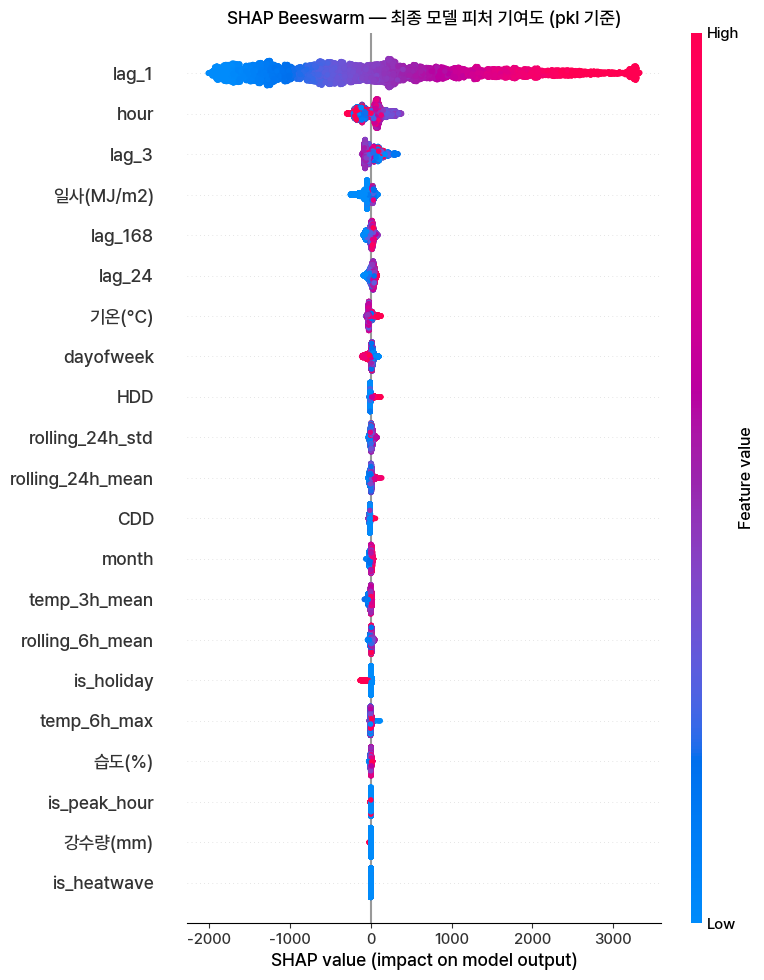

저장 완료


In [6]:
fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    show=False,
    max_display=21
)
plt.title("SHAP Beeswarm — 최종 모델 피처 기여도 (pkl 기준)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE + r"\4_outputs\12_SHAP_final\shap_beeswarm_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료")

## 5. [시각화 2] 피처 중요도 Bar Chart (평균 |SHAP|)

- 피처 그룹 구분:
  - **LAG 변수** (lag_1, lag_3, lag_24, lag_168, rolling_6h_mean, rolling_24h_mean, rolling_24h_std)
  - **환경 변수** (기온, 강수량, 습도, 일사, CDD, HDD, is_heatwave, temp_3h_mean, temp_6h_max)
  - **시간 변수** (hour, dayofweek, month, is_holiday, is_peak_hour)


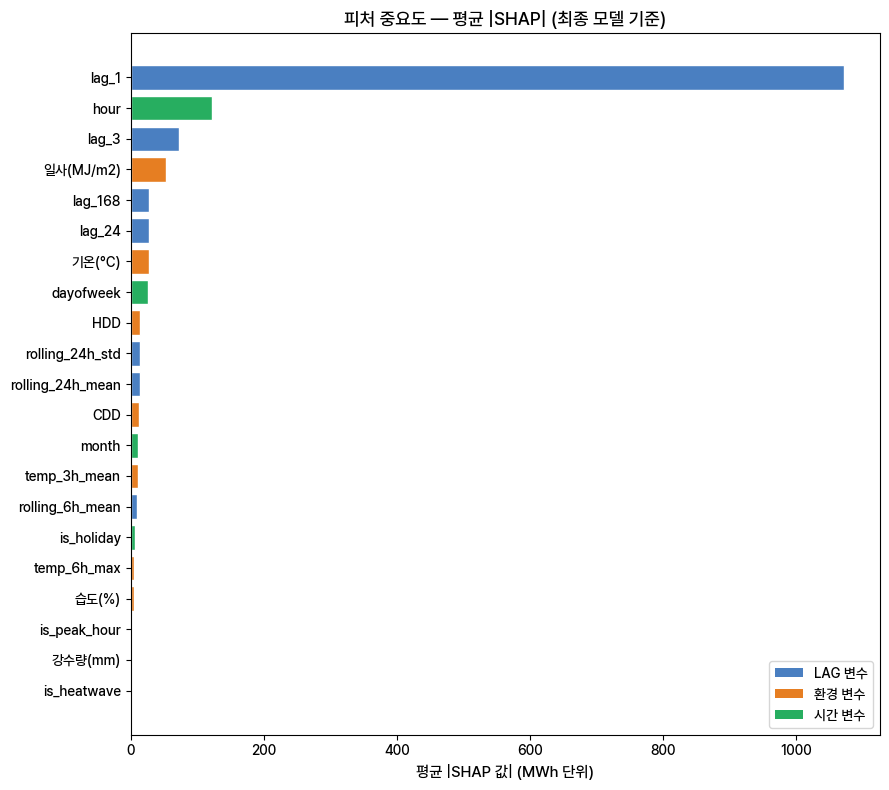

저장 완료


In [7]:
LAG_FEATURES  = ["lag_1", "lag_3", "lag_24", "lag_168",
                  "rolling_6h_mean", "rolling_24h_mean", "rolling_24h_std"]
ENV_FEATURES  = ["기온(°C)", "강수량(mm)", "습도(%)", "일사(MJ/m2)",
                  "CDD", "HDD", "is_heatwave", "temp_3h_mean", "temp_6h_max"]
TIME_FEATURES = ["hour", "dayofweek", "month", "is_holiday", "is_peak_hour"]

mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURES
).sort_values(ascending=True)

colors = []
for f in mean_abs_shap.index:
    if f in LAG_FEATURES:  colors.append("#4A7FC1")
    elif f in ENV_FEATURES: colors.append("#E67E22")
    else:                   colors.append("#27AE60")

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(mean_abs_shap.index, mean_abs_shap.values, color=colors, edgecolor="white")
ax.set_xlabel("평균 |SHAP 값| (MWh 단위)", fontsize=11)
ax.set_title("피처 중요도 — 평균 |SHAP| (최종 모델 기준)", fontsize=13, fontweight="bold")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4A7FC1", label="LAG 변수"),
    Patch(facecolor="#E67E22", label="환경 변수"),
    Patch(facecolor="#27AE60", label="시간 변수"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig(BASE + r"\4_outputs\12_SHAP_final\shap_bar_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료")

## 6. [시각화 3] CDD vs HDD — SHAP Dependence Plot

- CDD / HDD 실제 값 구간에 따른 SHAP 기여도 변화 비교
- **핵심 질문**: CDD가 올라갈수록 SHAP이 얼마나 증가하는가?
- 06_SHAP의 기온·CDD·HDD 3종 비교에서 → 최종 모델에서 기온 제외된 구조 반영


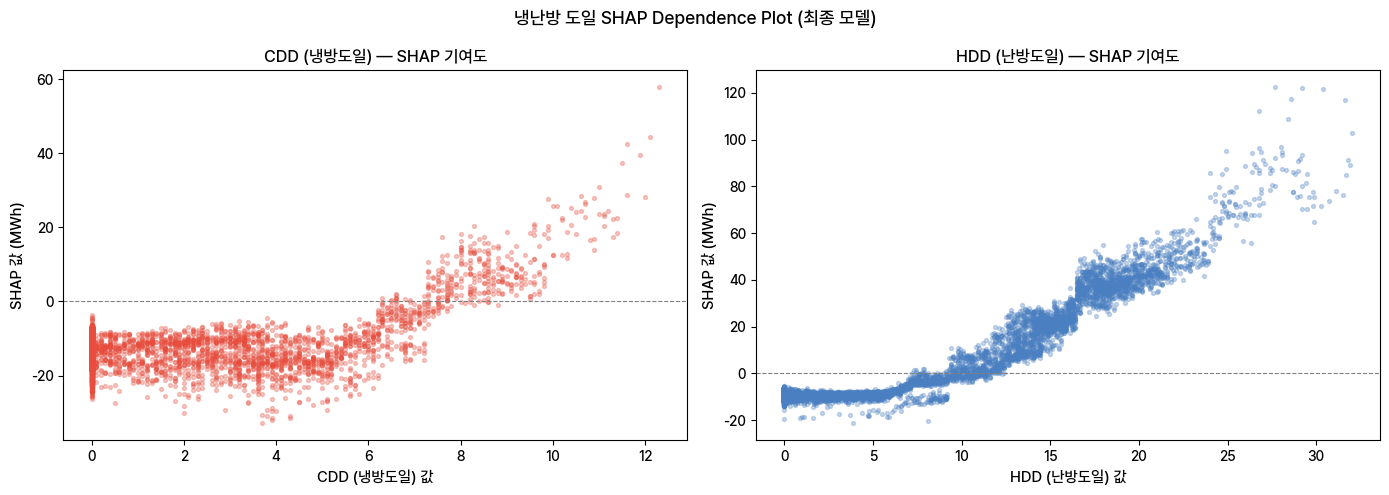

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat, title, color in zip(
    axes,
    ["CDD", "HDD"],
    ["CDD (냉방도일)", "HDD (난방도일)"],
    ["#E74C3C", "#4A7FC1"]
):
    feat_idx = FEATURES.index(feat)
    ax.scatter(
        X_test[feat],
        shap_values[:, feat_idx],
        c=color, alpha=0.3, s=8
    )
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(f"{title} 값", fontsize=11)
    ax.set_ylabel("SHAP 값 (MWh)", fontsize=11)
    ax.set_title(f"{title} — SHAP 기여도", fontsize=12, fontweight="bold")

fig.suptitle("냉난방 도일 SHAP Dependence Plot (최종 모델)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE + r"\4_outputs\12_SHAP_final\shap_dependence_final.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. [시각화 4] 폭염 vs 일반 구간 SHAP 비교

- is_heatwave=1 (폭염) vs is_heatwave=0 (일반) 구분
- **최종 모델에는 is_heatwave 피처가 직접 포함** → 06_SHAP의 불쾌지수 기준과 다름
- 폭염 구간에서 어떤 변수의 SHAP이 폭발적으로 증가하는지 확인


폭염 구간 (is_heatwave=1) : 107행
일반 구간 (is_heatwave=0) : 8677행


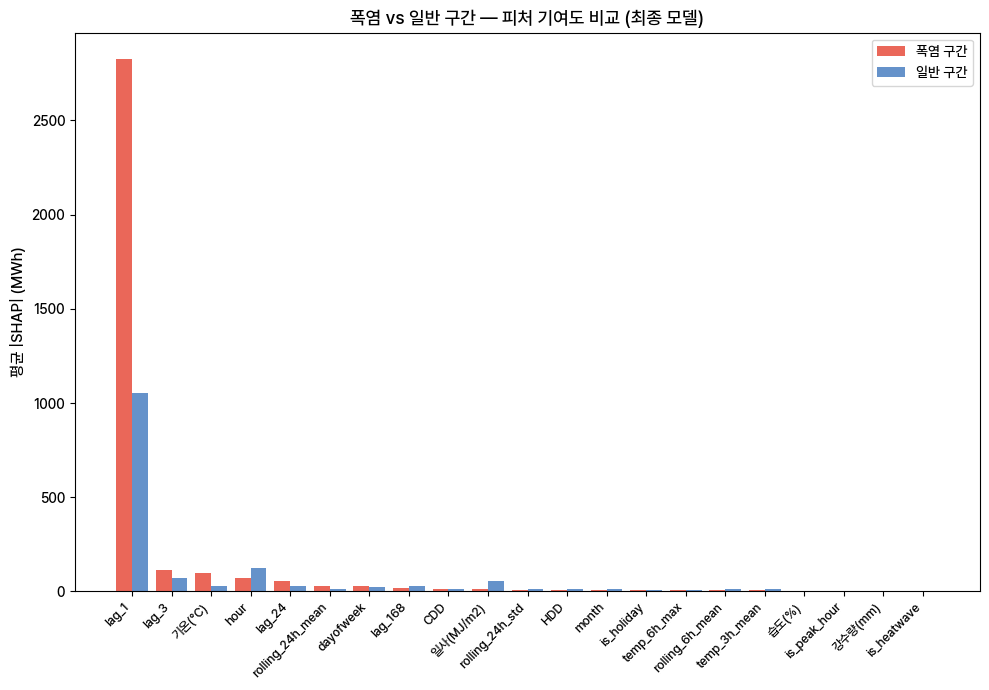

In [9]:
heatwave_mask = X_test["is_heatwave"].values == 1
normal_mask   = ~heatwave_mask

print(f"폭염 구간 (is_heatwave=1) : {heatwave_mask.sum()}행")
print(f"일반 구간 (is_heatwave=0) : {normal_mask.sum()}행")

shap_hw  = pd.Series(np.abs(shap_values[heatwave_mask]).mean(axis=0),  index=FEATURES)
shap_nor = pd.Series(np.abs(shap_values[normal_mask]).mean(axis=0),    index=FEATURES)

compare = pd.DataFrame({"폭염 구간": shap_hw, "일반 구간": shap_nor}).sort_values("폭염 구간", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(len(compare))
w = 0.4
ax.bar(x - w/2, compare["폭염 구간"], width=w, label="폭염 구간", color="#E74C3C", alpha=0.85)
ax.bar(x + w/2, compare["일반 구간"], width=w, label="일반 구간", color="#4A7FC1", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(compare.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("평균 |SHAP| (MWh)", fontsize=11)
ax.set_title("폭염 vs 일반 구간 — 피처 기여도 비교 (최종 모델)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(BASE + r"\4_outputs\12_SHAP_final\shap_heatwave_final.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. [시각화 5] 개별 예측 설명 — Waterfall Plot

- 여름 피크 최고 수요 시점에서 각 피처가 예측값에 어떻게 기여했는지 분해
- **기준값(Base value)** = 학습 데이터 전체 평균 전력 수요


선택 시점  : 2024-08-20 14:00:00
실제 수요  : 10239 MWh
예측 수요  : 8946 MWh


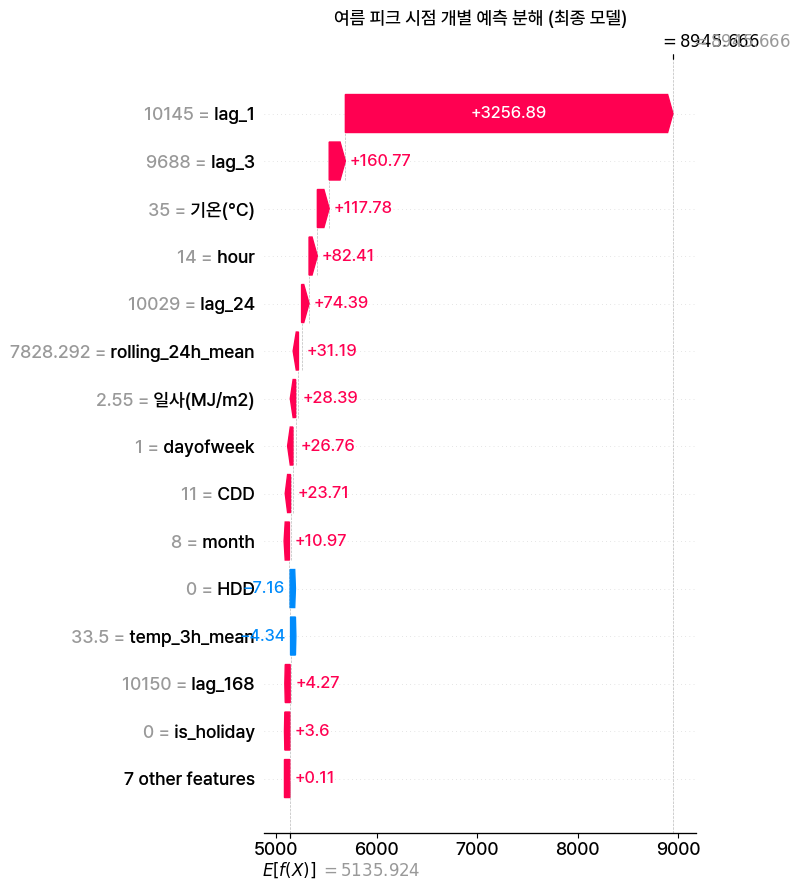

In [10]:
# 여름 피크(6~8월, 14시)에서 최고 수요 시점 선택
summer_test  = test[(test["datetime"].dt.month.isin([6,7,8])) & (test["datetime"].dt.hour == 14)]
peak_idx     = y_test.loc[summer_test.index].idxmax()
peak_pos     = X_test.index.get_loc(peak_idx)

print(f"선택 시점  : {test.loc[peak_idx, 'datetime']}")
print(f"실제 수요  : {y_test.loc[peak_idx]:.0f} MWh")
print(f"예측 수요  : {model.predict(X_test.iloc[[peak_pos]])[0]:.0f} MWh")

# Waterfall
shap_exp = shap.Explanation(
    values         = shap_values[peak_pos],
    base_values    = explainer.expected_value,
    data           = X_test.iloc[peak_pos].values,
    feature_names  = FEATURES
)
plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title("여름 피크 시점 개별 예측 분해 (최종 모델)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(BASE + r"\4_outputs\12_SHAP_final\shap_waterfall_final.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. 핵심 수치 요약

In [11]:
# 피처 그룹별 기여도 합산
group_contrib = {
    "LAG 변수"  : np.abs(shap_values[:, [FEATURES.index(f) for f in LAG_FEATURES]]).mean(),
    "환경 변수" : np.abs(shap_values[:, [FEATURES.index(f) for f in ENV_FEATURES]]).mean(),
    "시간 변수" : np.abs(shap_values[:, [FEATURES.index(f) for f in TIME_FEATURES]]).mean(),
}
total = sum(group_contrib.values())

print("=" * 45)
print("  피처 그룹별 평균 |SHAP| 기여도")
print("=" * 45)
for group, val in sorted(group_contrib.items(), key=lambda x: -x[1]):
    print(f"  {group:<10} : {val:6.1f} MWh  ({val/total*100:.1f}%)")
print("=" * 45)
print()

# Top 5 피처
top5 = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES).sort_values(ascending=False).head(5)
print("  Top 5 피처 (평균 |SHAP|)")
print("-" * 35)
for feat, val in top5.items():
    print(f"  {feat:<25} : {val:.1f} MWh")

  피처 그룹별 평균 |SHAP| 기여도
  LAG 변수     :  176.7 MWh  (78.9%)
  시간 변수      :   33.2 MWh  (14.8%)
  환경 변수      :   14.2 MWh  (6.3%)

  Top 5 피처 (평균 |SHAP|)
-----------------------------------
  lag_1                     : 1072.2 MWh
  hour                      : 121.8 MWh
  lag_3                     : 72.2 MWh
  일사(MJ/m2)                 : 53.4 MWh
  lag_168                   : 28.4 MWh
